## Build training dataset pipeline

In [1]:
import json
from pathlib import Path

import numpy as np
from PIL import Image
from tqdm.auto import tqdm

In [2]:
ALLOWED_CLASS_ID_TO_NAME = {
    24: "person",
    25: "rider",
    26: "car",
    27: "truck",
    28: "bus",
    31: "train",
    32: "motorcycle",
    33: "bicycle",
}


def load_instance_map(path: Path) -> np.ndarray:
    arr = np.array(Image.open(path))
    if arr.ndim != 2:
        raise ValueError(f"Expected single-channel instance map, got shape {arr.shape} from {path}")
    return arr


def load_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    return np.array(img)


def bbox_from_mask(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1 = int(xs.min())
    y1 = int(ys.min())
    x2 = int(xs.max())
    y2 = int(ys.max())
    return x1, y1, x2, y2


def clamp_bbox(x1, y1, x2, y2, w, h):
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w - 1))
    y2 = max(0, min(y2, h - 1))
    return x1, y1, x2, y2


def save_rgba_object_patch(
    rgb: np.ndarray,
    mask: np.ndarray,
    bbox,
    out_path: Path,
    context_pad: int = 4,
):
    h, w = rgb.shape[:2]
    x1, y1, x2, y2 = bbox

    x1p, y1p, x2p, y2p = clamp_bbox(
        x1 - context_pad,
        y1 - context_pad,
        x2 + context_pad,
        y2 + context_pad,
        w,
        h,
    )

    crop_rgb = rgb[y1p:y2p + 1, x1p:x2p + 1].copy()
    crop_mask = mask[y1p:y2p + 1, x1p:x2p + 1].copy()

    alpha = (crop_mask.astype(np.uint8) * 255)
    rgba = np.dstack([crop_rgb, alpha])

    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(rgba).save(out_path)

    return {
        "crop_bbox_xyxy_abs": [x1p, y1p, x2p, y2p],
        "crop_size_wh": [int(x2p - x1p + 1), int(y2p - y1p + 1)],
    }


def process_one_image(
    rgb_path: Path,
    instance_path: Path,
    out_objects_dir: Path,
    split: str,
    min_area: int,
    context_pad: int,
):
    rgb = load_rgb(rgb_path)
    inst = load_instance_map(instance_path)

    h, w = inst.shape
    records = []

    unique_ids = np.unique(inst)

    for instance_id in unique_ids:
        instance_id = int(instance_id)

        if instance_id < 1000:
            continue

        class_id = instance_id // 1000
        if class_id not in ALLOWED_CLASS_ID_TO_NAME:
            continue

        class_name = ALLOWED_CLASS_ID_TO_NAME[class_id]
        mask = (inst == instance_id)

        area = int(mask.sum())
        if area < min_area:
            continue

        bbox = bbox_from_mask(mask)
        if bbox is None:
            continue

        x1, y1, x2, y2 = bbox
        bw = int(x2 - x1 + 1)
        bh = int(y2 - y1 + 1)

        stem = rgb_path.stem.replace("_leftImg8bit", "")
        obj_name = f"{stem}_{class_name}_{instance_id}"
        obj_rel_path = Path(split) / "objects" / class_name / f"{obj_name}.png"
        obj_abs_path = out_objects_dir / class_name / f"{obj_name}.png"

        crop_meta = save_rgba_object_patch(
            rgb=rgb,
            mask=mask,
            bbox=bbox,
            out_path=obj_abs_path,
            context_pad=context_pad,
        )

        record = {
            "sample_id": obj_name,
            "split": split,
            "city": rgb_path.parent.name,
            "source_image_name": rgb_path.name,
            "source_image_rel": str(Path("leftImg8bit") / split / rgb_path.parent.name / rgb_path.name),
            "instance_map_rel": str(Path("gtFine") / split / instance_path.parent.name / instance_path.name),
            "class_name": class_name,
            "class_id": class_id,
            "instance_id": instance_id,
            "image_size_wh": [w, h],
            "bbox_xyxy_abs": [x1, y1, x2, y2],
            "bbox_wh_abs": [bw, bh],
            "mask_area": area,
            "object_patch_rel": str(obj_rel_path),
            "crop_bbox_xyxy_abs": crop_meta["crop_bbox_xyxy_abs"],
            "crop_size_wh": crop_meta["crop_size_wh"],
        }
        records.append(record)

    return records


def build_cityscapes_objects_notebook(
    cityscapes_root,
    out_root,
    split="train",
    min_area=256,
    context_pad=4,
    max_images=-1,
):
    city_root = Path(cityscapes_root)
    out_root = Path(out_root)

    left_root = city_root / "leftImg8bit" / split
    fine_root = city_root / "gtFine" / split

    if not left_root.exists():
        raise FileNotFoundError(f"Not found: {left_root}")
    if not fine_root.exists():
        raise FileNotFoundError(f"Not found: {fine_root}")

    out_split_root = out_root / split
    out_objects_dir = out_split_root / "objects"
    out_split_root.mkdir(parents=True, exist_ok=True)

    instance_paths = sorted(fine_root.glob("*/*_gtFine_instanceIds.png"))
    if max_images > 0:
        instance_paths = instance_paths[:max_images]

    print(f"split = {split}")
    print(f"num instance maps to scan = {len(instance_paths)}")
    print(f"output root = {out_split_root}")

    all_records = []
    class_counter = {name: 0 for name in ALLOWED_CLASS_ID_TO_NAME.values()}

    for inst_path in tqdm(instance_paths):
        city = inst_path.parent.name
        stem = inst_path.name.replace("_gtFine_instanceIds.png", "")
        rgb_name = f"{stem}_leftImg8bit.png"
        rgb_path = left_root / city / rgb_name

        if not rgb_path.exists():
            print(f"[WARN] Missing RGB image, skip: {rgb_path}")
            continue

        records = process_one_image(
            rgb_path=rgb_path,
            instance_path=inst_path,
            out_objects_dir=out_objects_dir,
            split=split,
            min_area=min_area,
            context_pad=context_pad,
        )

        for r in records:
            class_counter[r["class_name"]] += 1
        all_records.extend(records)

    index_path = out_split_root / f"index_{split}.jsonl"
    with open(index_path, "w", encoding="utf-8") as f:
        for r in all_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    summary = {
        "split": split,
        "num_source_images": len(instance_paths),
        "num_objects": len(all_records),
        "class_counter": class_counter,
        "min_area": min_area,
        "context_pad": context_pad,
    }

    summary_path = out_split_root / f"summary_{split}.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("\nDone.")
    print(f"index saved to: {index_path}")
    print(f"summary saved to: {summary_path}")
    print("class counts:")
    for k, v in class_counter.items():
        print(f"  {k:12s} {v}")

    return {
        "index_path": index_path,
        "summary_path": summary_path,
        "out_split_root": out_split_root,
        "num_records": len(all_records),
        "records": all_records,
    }

In [33]:
CITYSCAPES_ROOT = "./data"
OUT_ROOT = "./bootplace_like_data"

result = build_cityscapes_objects_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="train",
    min_area=256,
    context_pad=4,
    max_images=20,
)

split = train
num instance maps to scan = 20
output root = bootplace_like_data\train


  0%|          | 0/20 [00:00<?, ?it/s]


Done.
index saved to: bootplace_like_data\train\index_train.jsonl
summary saved to: bootplace_like_data\train\summary_train.json
class counts:
  person       196
  rider        10
  car          172
  truck        0
  bus          7
  train        0
  motorcycle   10
  bicycle      23


In [34]:
print("index path:", result["index_path"])
print("summary path:", result["summary_path"])
print("num records:", result["num_records"])

with open(result["summary_path"], "r", encoding="utf-8") as f:
    summary = json.load(f)

summary

index path: bootplace_like_data\train\index_train.jsonl
summary path: bootplace_like_data\train\summary_train.json
num records: 418


{'split': 'train',
 'num_source_images': 20,
 'num_objects': 418,
 'class_counter': {'person': 196,
  'rider': 10,
  'car': 172,
  'truck': 0,
  'bus': 7,
  'train': 0,
  'motorcycle': 10,
  'bicycle': 23},
 'min_area': 256,
 'context_pad': 4}

num object patches = 418
first patch = bootplace_like_data\train\objects\bicycle\aachen_000000_000019_bicycle_33000.png


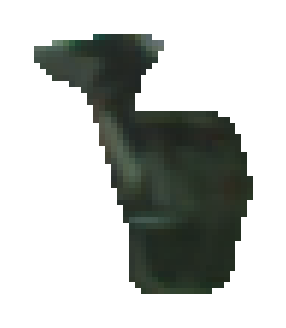

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

obj_root = Path(result["out_split_root"]) / "objects"
all_pngs = sorted(obj_root.glob("*/*.png"))

print("num object patches =", len(all_pngs))
print("first patch =", all_pngs[0] if len(all_pngs) > 0 else None)

if len(all_pngs) > 0:
    img = Image.open(all_pngs[0]).convert("RGBA")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [3]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import cv2

In [4]:
def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def load_instance_map(path: Path) -> np.ndarray:
    arr = np.array(Image.open(path))
    if arr.ndim != 2:
        raise ValueError(f"Expected single-channel instance map, got shape {arr.shape} from {path}")
    return arr


def make_prompt_text(class_name: str) -> str:
    article = "an" if class_name[0].lower() in ["a", "e", "i", "o", "u"] else "a"
    return f"place {article} {class_name}"


def inpaint_remove_instance(
    rgb: np.ndarray,
    target_mask: np.ndarray,
    dilate_ksize: int = 9,
    inpaint_radius: int = 3,
):
    """
    用 OpenCV inpaint 去掉目标实例。
    返回：
    - background_rgb
    - used_mask_u8
    """
    mask_u8 = (target_mask.astype(np.uint8) * 255)

    if dilate_ksize > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_ksize, dilate_ksize))
        mask_u8 = cv2.dilate(mask_u8, kernel, iterations=1)

    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    bg_bgr = cv2.inpaint(bgr, mask_u8, inpaintRadius=inpaint_radius, flags=cv2.INPAINT_TELEA)
    bg_rgb = cv2.cvtColor(bg_bgr, cv2.COLOR_BGR2RGB)

    return bg_rgb, mask_u8


def draw_box(ax, box, color="red", text=None, linestyle="-", linewidth=2):
    if box is None:
        return
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none",
        linestyle=linestyle,
    )
    ax.add_patch(rect)

    if text is not None:
        ax.text(
            x1,
            max(0, y1 - 5),
            text,
            fontsize=10,
            bbox=dict(facecolor="yellow", alpha=0.65),
        )

In [10]:
import random
def build_cityscapes_backgrounds_notebook(
    cityscapes_root,
    out_root,
    split="train",
    index_path=None,
    max_samples=-1,
    dilate_ksize=9,
    inpaint_radius=3,
    max_targets_per_image=None,
    random_seed=42,
):
    city_root = Path(cityscapes_root)
    out_root = Path(out_root)
    split_root = out_root / split

    if index_path is None:
        index_path = split_root / f"index_{split}.jsonl"
    else:
        index_path = Path(index_path)

    if not index_path.exists():
        raise FileNotFoundError(f"Not found: {index_path}")

    records = read_jsonl(index_path)
    print(f"loaded object records = {len(records)}")

    if max_samples > 0:
        records = records[:max_samples]
        print(f"use first {len(records)} records for smoke test")

    bg_dir = split_root / "backgrounds"
    loc_dir = split_root / "location"
    bg_dir.mkdir(parents=True, exist_ok=True)
    loc_dir.mkdir(parents=True, exist_ok=True)

    grouped = defaultdict(list)
    for r in records:
        grouped[r["source_image_rel"]].append(r)

    print(f"num grouped source images = {len(grouped)}")

    rng = random.Random(random_seed)
    final_records = []

    for source_rel, group_records in tqdm(grouped.items()):
        rgb_path = city_root / source_rel
        inst_path = city_root / group_records[0]["instance_map_rel"]

        rgb = load_rgb(rgb_path)
        inst = load_instance_map(inst_path)

        # 同一张原图里的所有对象，仍然都作为 scene objects 保留
        all_boxes_same_image = []
        for r in group_records:
            all_boxes_same_image.append({
                "sample_id": r["sample_id"],
                "class_name": r["class_name"],
                "instance_id": r["instance_id"],
                "bbox_xyxy_abs": r["bbox_xyxy_abs"],
            })

        # 关键改动：每张图只选部分 target 来生成 background
        selected_targets = group_records
        if max_targets_per_image is not None and len(group_records) > max_targets_per_image:
            selected_targets = rng.sample(group_records, k=max_targets_per_image)

        for target in selected_targets:
            target_instance_id = int(target["instance_id"])
            target_bbox = target["bbox_xyxy_abs"]
            target_class = target["class_name"]
            sample_id = target["sample_id"]

            target_mask = (inst == target_instance_id)
            if target_mask.sum() == 0:
                print(f"[WARN] empty target mask: {sample_id}")
                continue

            bg_rgb, used_mask_u8 = inpaint_remove_instance(
                rgb=rgb,
                target_mask=target_mask,
                dilate_ksize=dilate_ksize,
                inpaint_radius=inpaint_radius,
            )

            bg_rel = Path(split) / "backgrounds" / f"{sample_id}.png"
            bg_abs = bg_dir / f"{sample_id}.png"
            Image.fromarray(bg_rgb).save(bg_abs)

            # scene boxes = 同一张图里除了 target 自己以外的其他对象
            scene_boxes = []
            for obj in all_boxes_same_image:
                if int(obj["instance_id"]) == target_instance_id:
                    continue
                scene_boxes.append({
                    "class_name": obj["class_name"],
                    "instance_id": obj["instance_id"],
                    "bbox_xyxy_abs": obj["bbox_xyxy_abs"],
                })

            loc_data = {
                "sample_id": sample_id,
                "prompt": make_prompt_text(target_class),
                "target_class": target_class,
                "target_instance_id": target_instance_id,
                "target_bbox_xyxy_abs": target_bbox,
                "scene_boxes_xyxy_abs": scene_boxes,
                "image_size_wh": target["image_size_wh"],
                "background_rel": str(bg_rel),
                "object_patch_rel": target["object_patch_rel"],
                "source_image_rel": target["source_image_rel"],
                "instance_map_rel": target["instance_map_rel"],
            }

            loc_path = loc_dir / f"{sample_id}.json"
            with open(loc_path, "w", encoding="utf-8") as f:
                json.dump(loc_data, f, ensure_ascii=False, indent=2)

            final_records.append(loc_data)

    annotations_path = split_root / f"annotations_{split}.jsonl"
    with open(annotations_path, "w", encoding="utf-8") as f:
        for r in final_records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    summary = {
        "split": split,
        "num_samples": len(final_records),
        "num_source_images": len(grouped),
        "background_dir": str(bg_dir),
        "location_dir": str(loc_dir),
        "annotations_path": str(annotations_path),
        "dilate_ksize": dilate_ksize,
        "inpaint_radius": inpaint_radius,
        "max_targets_per_image": max_targets_per_image,
    }

    summary_path = split_root / f"summary_backgrounds_{split}.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("\nDone.")
    print(f"backgrounds saved to: {bg_dir}")
    print(f"location jsons saved to: {loc_dir}")
    print(f"annotations saved to: {annotations_path}")
    print(f"summary saved to: {summary_path}")

    return {
        "background_dir": bg_dir,
        "location_dir": loc_dir,
        "annotations_path": annotations_path,
        "summary_path": summary_path,
        "records": final_records,
    }

In [ ]:
bg_result = build_cityscapes_backgrounds_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="train",
    index_path=result["index_path"],
    max_samples=-1,
    dilate_ksize=9,
    inpaint_radius=3,
)

loaded object records = 418
num grouped source images = 20


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print("background_dir =", bg_result["background_dir"])
print("location_dir =", bg_result["location_dir"])
print("annotations_path =", bg_result["annotations_path"])
print("num samples =", len(bg_result["records"]))

with open(bg_result["summary_path"], "r", encoding="utf-8") as f:
    bg_summary = json.load(f)

bg_summary

background_dir = bootplace_like_data\train\backgrounds
location_dir = bootplace_like_data\train\location
annotations_path = bootplace_like_data\train\annotations_train.jsonl
num samples = 418


{'split': 'train',
 'num_samples': 418,
 'background_dir': 'bootplace_like_data\\train\\backgrounds',
 'location_dir': 'bootplace_like_data\\train\\location',
 'annotations_path': 'bootplace_like_data\\train\\annotations_train.jsonl',
 'dilate_ksize': 9,
 'inpaint_radius': 3}

In [ ]:
sample = bg_result["records"][9]
sample

{'sample_id': 'aachen_000000_000019_car_26010',
 'prompt': 'place a car',
 'target_class': 'car',
 'target_instance_id': 26010,
 'target_bbox_xyxy_abs': [609, 420, 807, 531],
 'scene_boxes_xyxy_abs': [{'class_name': 'person',
   'instance_id': 24000,
   'bbox_xyxy_abs': [892, 446, 912, 497]},
  {'class_name': 'person',
   'instance_id': 24001,
   'bbox_xyxy_abs': [901, 444, 934, 497]},
  {'class_name': 'rider',
   'instance_id': 25000,
   'bbox_xyxy_abs': [1831, 440, 1887, 547]},
  {'class_name': 'car',
   'instance_id': 26003,
   'bbox_xyxy_abs': [1966, 488, 2042, 521]},
  {'class_name': 'car',
   'instance_id': 26004,
   'bbox_xyxy_abs': [1512, 446, 1660, 498]},
  {'class_name': 'car',
   'instance_id': 26005,
   'bbox_xyxy_abs': [1479, 456, 1634, 513]},
  {'class_name': 'car',
   'instance_id': 26007,
   'bbox_xyxy_abs': [1876, 486, 1955, 512]},
  {'class_name': 'car',
   'instance_id': 26008,
   'bbox_xyxy_abs': [1721, 450, 1850, 508]},
  {'class_name': 'car',
   'instance_id': 260

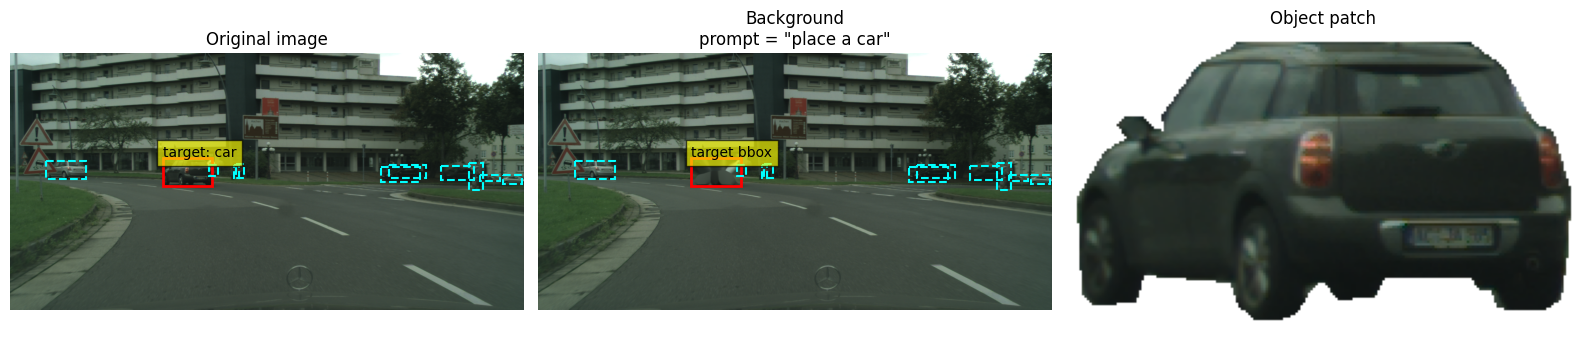

In [ ]:
sample = bg_result["records"][9]

source_img = Image.open(Path(CITYSCAPES_ROOT) / sample["source_image_rel"]).convert("RGB")
bg_img = Image.open(Path(OUT_ROOT) / sample["background_rel"]).convert("RGB")
obj_img = Image.open(Path(OUT_ROOT) / sample["object_patch_rel"]).convert("RGBA")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(source_img)
axes[0].set_title("Original image")
axes[0].axis("off")

draw_box(
    axes[0],
    sample["target_bbox_xyxy_abs"],
    color="red",
    text=f'target: {sample["target_class"]}',
)
for s in sample["scene_boxes_xyxy_abs"][:10]:
    draw_box(
        axes[0],
        s["bbox_xyxy_abs"],
        color="cyan",
        text=None,
        linestyle="--",
        linewidth=1.5,
    )

axes[1].imshow(bg_img)
axes[1].set_title(f'Background\nprompt = "{sample["prompt"]}"')
axes[1].axis("off")

draw_box(
    axes[1],
    sample["target_bbox_xyxy_abs"],
    color="red",
    text="target bbox",
)
for s in sample["scene_boxes_xyxy_abs"][:10]:
    draw_box(
        axes[1],
        s["bbox_xyxy_abs"],
        color="cyan",
        text=None,
        linestyle="--",
        linewidth=1.5,
    )

axes[2].imshow(obj_img)
axes[2].set_title("Object patch")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Build larger dataset

In [6]:
from pathlib import Path
import json

CITYSCAPES_ROOT = "./data"
OUT_ROOT = "./bootplace_like_data"

RUN_FULL_TRAIN = True
RUN_FULL_VAL = True

TRAIN_MAX_IMAGES = -1 if RUN_FULL_TRAIN else 500
VAL_MAX_IMAGES = -1 if RUN_FULL_VAL else 200

MIN_AREA = 256
CONTEXT_PAD = 4
DILATE_KSIZE = 9
INPAINT_RADIUS = 3

In [7]:
train_obj_result = build_cityscapes_objects_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="train",
    min_area=MIN_AREA,
    context_pad=CONTEXT_PAD,
    max_images=TRAIN_MAX_IMAGES,
)

split = train
num instance maps to scan = 2975
output root = bootplace_like_data\train


  0%|          | 0/2975 [00:00<?, ?it/s]


Done.
index saved to: bootplace_like_data\train\index_train.jsonl
summary saved to: bootplace_like_data\train\summary_train.json
class counts:
  person       14527
  rider        1581
  car          24151
  truck        469
  bus          372
  train        165
  motorcycle   675
  bicycle      3269


In [8]:
with open(train_obj_result["summary_path"], "r", encoding="utf-8") as f:
    train_obj_summary = json.load(f)

train_obj_summary

{'split': 'train',
 'num_source_images': 2975,
 'num_objects': 45209,
 'class_counter': {'person': 14527,
  'rider': 1581,
  'car': 24151,
  'truck': 469,
  'bus': 372,
  'train': 165,
  'motorcycle': 675,
  'bicycle': 3269},
 'min_area': 256,
 'context_pad': 4}

In [11]:
train_bg_result = build_cityscapes_backgrounds_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="train",
    index_path=train_obj_result["index_path"],
    max_samples=-1,
    dilate_ksize=DILATE_KSIZE,
    inpaint_radius=INPAINT_RADIUS,
    max_targets_per_image=3,
    random_seed=42,
)

loaded object records = 45209
num grouped source images = 2964


  0%|          | 0/2964 [00:00<?, ?it/s]


Done.
backgrounds saved to: bootplace_like_data\train\backgrounds
location jsons saved to: bootplace_like_data\train\location
annotations saved to: bootplace_like_data\train\annotations_train.jsonl
summary saved to: bootplace_like_data\train\summary_backgrounds_train.json


In [12]:
with open(train_bg_result["summary_path"], "r", encoding="utf-8") as f:
    train_bg_summary = json.load(f)

train_bg_summary

{'split': 'train',
 'num_samples': 8798,
 'num_source_images': 2964,
 'background_dir': 'bootplace_like_data\\train\\backgrounds',
 'location_dir': 'bootplace_like_data\\train\\location',
 'annotations_path': 'bootplace_like_data\\train\\annotations_train.jsonl',
 'dilate_ksize': 9,
 'inpaint_radius': 3,
 'max_targets_per_image': 3}

In [13]:
val_obj_result = build_cityscapes_objects_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="val",
    min_area=MIN_AREA,
    context_pad=CONTEXT_PAD,
    max_images=VAL_MAX_IMAGES,
)

split = val
num instance maps to scan = 500
output root = bootplace_like_data\val


  0%|          | 0/500 [00:00<?, ?it/s]


Done.
index saved to: bootplace_like_data\val\index_val.jsonl
summary saved to: bootplace_like_data\val\summary_val.json
class counts:
  person       2810
  rider        501
  car          4112
  truck        90
  bus          98
  train        22
  motorcycle   139
  bicycle      1070


In [14]:
with open(val_obj_result["summary_path"], "r", encoding="utf-8") as f:
    val_obj_summary = json.load(f)

val_obj_summary

{'split': 'val',
 'num_source_images': 500,
 'num_objects': 8842,
 'class_counter': {'person': 2810,
  'rider': 501,
  'car': 4112,
  'truck': 90,
  'bus': 98,
  'train': 22,
  'motorcycle': 139,
  'bicycle': 1070},
 'min_area': 256,
 'context_pad': 4}

In [15]:
val_bg_result = build_cityscapes_backgrounds_notebook(
    cityscapes_root=CITYSCAPES_ROOT,
    out_root=OUT_ROOT,
    split="val",
    index_path=val_obj_result["index_path"],
    max_samples=-1,
    dilate_ksize=DILATE_KSIZE,
    inpaint_radius=INPAINT_RADIUS,
    max_targets_per_image=2,
    random_seed=0,
)

loaded object records = 8842
num grouped source images = 492


  0%|          | 0/492 [00:00<?, ?it/s]


Done.
backgrounds saved to: bootplace_like_data\val\backgrounds
location jsons saved to: bootplace_like_data\val\location
annotations saved to: bootplace_like_data\val\annotations_val.jsonl
summary saved to: bootplace_like_data\val\summary_backgrounds_val.json


In [16]:
with open(val_bg_result["summary_path"], "r", encoding="utf-8") as f:
    val_bg_summary = json.load(f)

val_bg_summary

{'split': 'val',
 'num_samples': 980,
 'num_source_images': 492,
 'background_dir': 'bootplace_like_data\\val\\backgrounds',
 'location_dir': 'bootplace_like_data\\val\\location',
 'annotations_path': 'bootplace_like_data\\val\\annotations_val.jsonl',
 'dilate_ksize': 9,
 'inpaint_radius': 3,
 'max_targets_per_image': 2}